<h1>WeGo Public Transit</h1>

[WeGo Public Transit](https://www.wegotransit.com/) is a public transit system serving the Greater Nashville and Davidson County area. WeGo provides local and regional bus routes, the WeGo Star train service connecting Lebanon to downtown Nashville, along with several other transit services.

The data for this project can be downloaded from [here](https://drive.google.com/file/d/1iM4WjC9k3EXHPNc6q4AwDh_MEIpXvfMD/view?usp=sharing).

In this project, you'll be analyzing the on-time performance of buses to look for patterns and try to identify correlations to controllable or external factors. 

The main variable you will be studying in this project is **adherence**, which compares the actual departure time to the scheduled time and is included in the ADHERENCE column. A negative adherence value means that a bus left a time point late and a positive adherence indicates that the bus left the time point early. Buses with adherence values beyond negative 6 are generally considered late and beyond positive 1 are considered early. However, there is some additional logic where the staff applies waivers to allow early departures, such as an express bus that has already picked up everyone at a park-and-ride lot and is only dropping people off at the remaining stops, and also allows for early timepoint records for all records where TRIP_EDGE = 2 (end of trip), since it is not a problem if a bus ends its trip early as long as it didn't pass other timepoints early along the way. **Note:** When determining whether a bus is early or late, it is advised that you use the 'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT', and 'ADJUSTED_ONTIME_COUNT' columns in order to account for the adjustments.

In [1]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import seaborn as sns
import matplotlib.pyplot as plt
import squarify
import folium
from folium.plugins import HeatMap

In [3]:
wego = pd.read_csv("../data/Headway Data, 8-1-2023 to 9-30-2023.csv")

wego.head()

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,6.500000,NaN
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,NaN,0,0.000000,NaN
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,12.866666,5.0


In [4]:
wego['ADHERENCE'].head()

0   -2.133333
1   -2.450000
2   -0.933333
3    6.283333
4   -1.583333
Name: ADHERENCE, dtype: float64

In [5]:
wego.columns

Index(['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR',
       'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID',
       'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE',
       'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME',
       'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
       'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'ADJUSTED_EARLY_COUNT',
       'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT', 'STOP_CANCELLED',
       'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS',
       'SCHEDULED_LAYOVER_MINUTES'],
      dtype='object')

In [6]:
wego.dtypes

CALENDAR_ID                    int64
SERVICE_ABBR                   int64
ADHERENCE_ID                   int64
DATE                          object
ROUTE_ABBR                     int64
BLOCK_ABBR                     int64
OPERATOR                       int64
TRIP_ID                        int64
OVERLOAD_ID                    int64
ROUTE_DIRECTION_NAME          object
TIME_POINT_ABBR               object
ROUTE_STOP_SEQUENCE          float64
TRIP_EDGE                      int64
LATITUDE                     float64
LONGITUDE                    float64
SCHEDULED_TIME                object
ACTUAL_ARRIVAL_TIME           object
ACTUAL_DEPARTURE_TIME         object
ADHERENCE                    float64
SCHEDULED_HDWY               float64
ACTUAL_HDWY                  float64
HDWY_DEV                     float64
ADJUSTED_EARLY_COUNT           int64
ADJUSTED_LATE_COUNT            int64
ADJUSTED_ONTIME_COUNT          int64
STOP_CANCELLED                 int64
PREV_SCHED_STOP_CANCELLED    float64
I

In [7]:
wego['DATE'] = pd.to_datetime(wego['DATE'])

In [8]:
wego['DAY_OF_WEEK'] = wego['DATE'].dt.day_name()

<h2>What is the overall on-time performance, and what do the overall distribution of adherence look like?</h2>

In [9]:
ontime_total = sum(wego['ADJUSTED_ONTIME_COUNT'])

In [10]:
print(ontime_total)

270048


In [11]:
early_total = sum(wego['ADJUSTED_EARLY_COUNT'])
print(early_total)

9775


In [12]:
late_total = sum(wego['ADJUSTED_LATE_COUNT'])
print(late_total)

59038


In [13]:
overall_total = ontime_total + early_total + late_total
pct_ontime = ontime_total / overall_total
pct_early = early_total / overall_total
pct_late = late_total / overall_total
print("Total data points: " + str(overall_total) + '\n'
      + "On Time: " + f"{pct_ontime:.2%}" + "\n"
      + "Early: " + f"{pct_early:.2%}" + "\n"
      + "Late: " + f"{pct_late:.2%}")

Total data points: 338861
On Time: 79.69%
Early: 2.88%
Late: 17.42%


In [14]:
def time_dist(ontime_total, early_total, late_total):
    overall_total = ontime_total + early_total + late_total
    pct_ontime = ontime_total / overall_total
    pct_early = early_total / overall_total
    pct_late = late_total / overall_total
    return {'on_time' : pct_ontime, 'early' : pct_early, 'late' : pct_late}

In [15]:
print(wego['ADHERENCE'].min())

-948.533333


In [16]:
print(wego['ADHERENCE'].max())

88.383333


In [17]:
wego_early = wego.loc[wego['ADJUSTED_EARLY_COUNT'] == 1]

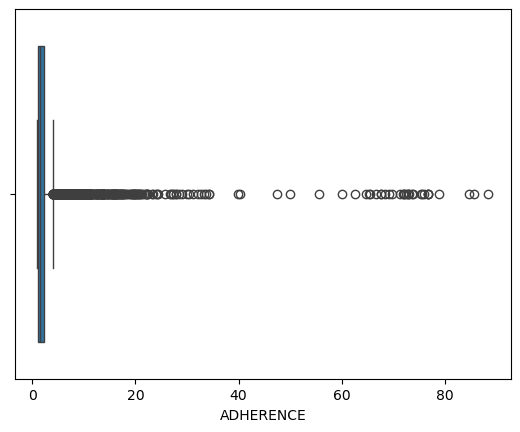

In [18]:
early_box = sns.boxplot(x=wego_early['ADHERENCE'])
fig = early_box.get_figure()
fig.savefig("early_boxplot.png")

In [19]:
wego_late = wego.loc[wego['ADJUSTED_LATE_COUNT'] == 1]

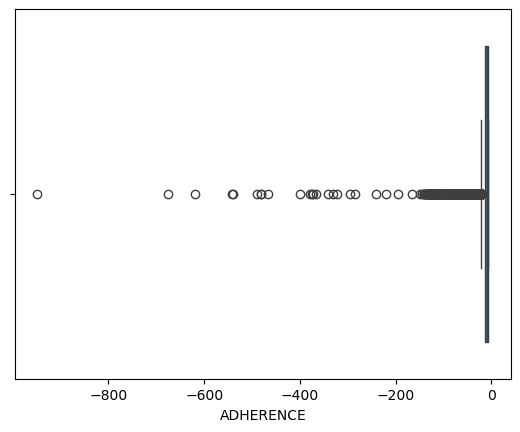

In [20]:
late_box = sns.boxplot(x=wego_late['ADHERENCE'])
fig = late_box.get_figure()
fig.savefig("late_boxplot.png")

In [21]:
wego_ontime = wego.loc[wego['ADJUSTED_ONTIME_COUNT'] == 1]

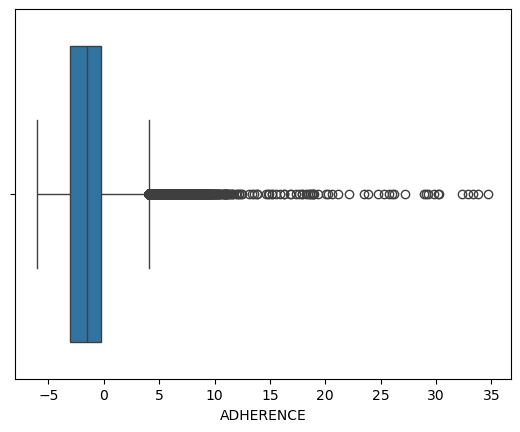

In [22]:
ontime_box = sns.boxplot(x=wego_ontime['ADHERENCE'])
fig = ontime_box.get_figure()
fig.savefig("ontime_boxplot.png")

<h2>How does direction of travel, route, or location affect the on-time performance?</h2>

<h3>Direction of Travel</h3>

In [23]:
wego_to_dntn = wego.loc[wego['ROUTE_DIRECTION_NAME'] == 'TO DOWNTOWN']

In [24]:
wego_from_dntn = wego.loc[wego['ROUTE_DIRECTION_NAME'] == 'FROM DOWNTOWN']

In [25]:
print(time_dist(sum(wego_to_dntn['ADJUSTED_ONTIME_COUNT']), sum(wego_to_dntn['ADJUSTED_EARLY_COUNT']), sum(wego_to_dntn['ADJUSTED_LATE_COUNT'])))

{'on_time': 0.8500767760333428, 'early': 0.02810316191908746, 'late': 0.1218200620475698}


In [26]:
print(time_dist(sum(wego_from_dntn['ADJUSTED_ONTIME_COUNT']), sum(wego_from_dntn['ADJUSTED_EARLY_COUNT']), sum(wego_from_dntn['ADJUSTED_LATE_COUNT'])))

{'on_time': 0.7496347026870267, 'early': 0.02950821500674824, 'late': 0.2208570823062251}


In [27]:
wego_direction = wego[['ROUTE_DIRECTION_NAME', 'ADJUSTED_ONTIME_COUNT', 'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT']]
wego_direction = wego_direction.groupby('ROUTE_DIRECTION_NAME').sum()

In [28]:
direction_dist = time_dist(wego_direction['ADJUSTED_ONTIME_COUNT'], wego_direction['ADJUSTED_EARLY_COUNT'], wego_direction['ADJUSTED_LATE_COUNT'])

In [29]:
direction_dist

{'on_time': ROUTE_DIRECTION_NAME
 FROM DOWNTOWN    0.749635
 TO DOWNTOWN      0.850077
 dtype: float64,
 'early': ROUTE_DIRECTION_NAME
 FROM DOWNTOWN    0.029508
 TO DOWNTOWN      0.028103
 dtype: float64,
 'late': ROUTE_DIRECTION_NAME
 FROM DOWNTOWN    0.220857
 TO DOWNTOWN      0.121820
 dtype: float64}

In [30]:
wego_direction['ONTIME_PCT'] = direction_dist['on_time']
wego_direction['EARLY_PCT'] = direction_dist['early']
wego_direction['LATE_PCT'] = direction_dist['late']

In [31]:
wego_direction

,ADJUSTED_ONTIME_COUNT,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ONTIME_PCT,EARLY_PCT,LATE_PCT
ROUTE_DIRECTION_NAME,,,,,,
FROM DOWNTOWN,134414,5291,39601,0.749635,0.029508,0.220857
TO DOWNTOWN,135634,4484,19437,0.850077,0.028103,0.121820


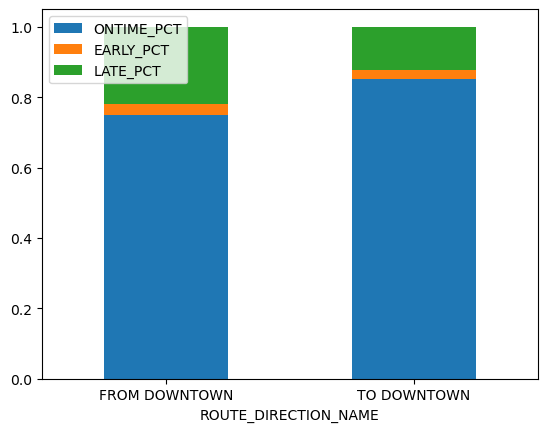

In [32]:
dir_box = wego_direction[['ONTIME_PCT', 'EARLY_PCT', 'LATE_PCT']].plot.bar(stacked=True, rot = 0)
fig = dir_box.get_figure()
fig.savefig("direction_dist_barplot.png")

<h3>Route</h3>

In [33]:
wego_route = wego[['ROUTE_ABBR', 'ADJUSTED_ONTIME_COUNT', 'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT']]
wego_route = wego_route.groupby('ROUTE_ABBR').sum()

In [34]:
wego_route

,ADJUSTED_ONTIME_COUNT,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT
ROUTE_ABBR,,,
3,34516,1382,9590
7,13417,433,3417
22,22492,631,2065
23,35137,1286,3230
50,36309,1207,5113
52,37736,1553,10038
55,42080,1531,16748
56,48361,1752,8837


In [35]:
route_dist = time_dist(wego_route['ADJUSTED_ONTIME_COUNT'], wego_route['ADJUSTED_EARLY_COUNT'], wego_route['ADJUSTED_LATE_COUNT'])

In [36]:
wego_route['ONTIME_PCT'] = route_dist['on_time']
wego_route['EARLY_PCT'] = route_dist['early']
wego_route['LATE_PCT'] = route_dist['late']

In [37]:
wego_route

,ADJUSTED_ONTIME_COUNT,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ONTIME_PCT,EARLY_PCT,LATE_PCT
ROUTE_ABBR,,,,,,
3,34516,1382,9590,0.758794,0.030382,0.210825
7,13417,433,3417,0.777031,0.025077,0.197892
22,22492,631,2065,0.892965,0.025052,0.081983
23,35137,1286,3230,0.886112,0.032431,0.081457
50,36309,1207,5113,0.851744,0.028314,0.119942
52,37736,1553,10038,0.765017,0.031484,0.203499
55,42080,1531,16748,0.697162,0.025365,0.277473
56,48361,1752,8837,0.820373,0.029720,0.149907


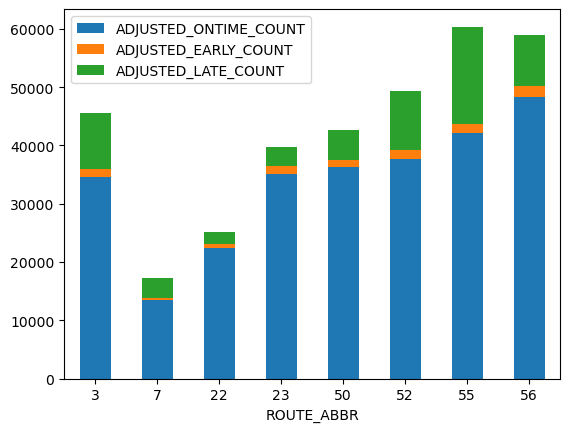

In [38]:
route_count = wego_route[['ADJUSTED_ONTIME_COUNT', 'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT']].plot.bar(stacked=True, rot = 0)
fig = route_count.get_figure()
fig.savefig("route_count_barplot.png")

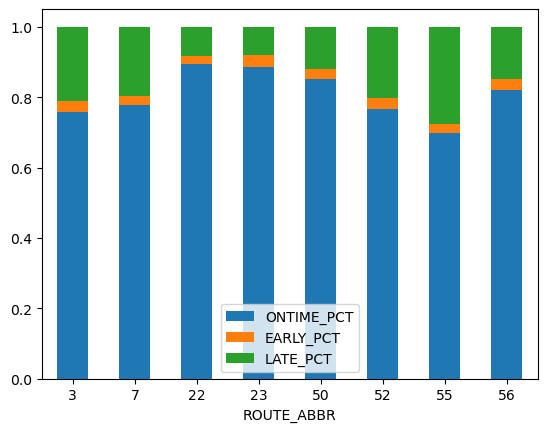

In [39]:
route_dist = wego_route[['ONTIME_PCT', 'EARLY_PCT', 'LATE_PCT']].plot.bar(stacked=True, rot = 0)
fig = route_dist.get_figure()
fig.savefig("route_dist_barplot.png")

<h3>Location</h3>

In [40]:
#Find average lat/long to know where to position the folium map
avg_lat = wego['LATITUDE'].mean()
avg_long = wego['LONGITUDE'].mean()
map_start = [avg_lat, avg_long]

In [41]:
early_map = folium.Map(map_start, zoom_start = 11)

In [42]:
HeatMap(wego_early[['LATITUDE', 'LONGITUDE']]).add_to(early_map)
#early_map

In [43]:
early_map.save("early_heatmap.html")

In [44]:
late_map = folium.Map(map_start, zoom_start = 11)

In [45]:
HeatMap(wego_late[['LATITUDE', 'LONGITUDE']]).add_to(late_map)
#late_map

In [46]:
late_map.save("late_heatmap.html")

In [47]:
wego_off = pd.concat([wego_early, wego_late])

In [48]:
off_map = folium.Map(map_start, zoom_start = 11)

In [49]:
HeatMap(wego_off[['LATITUDE', 'LONGITUDE']]).add_to(off_map)
#off_map

In [50]:
off_map.save("early_and_late_heatmap.html")

<h2>How does time of day or day of week affect on-time performance?</h2>

<h3>Time of Day</h3>

In [51]:
wego['HOUR'] = wego['SCHEDULED_TIME'].str[-8:-6]

In [52]:
wego['HOUR'] = wego['HOUR'].astype(int)

In [53]:
wego_hour = wego[['HOUR', 'ADJUSTED_ONTIME_COUNT', 'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT']]
wego_hour = wego_hour.groupby('HOUR').sum()

In [54]:
#wego_hour

In [55]:
hour_dist = time_dist(wego_hour['ADJUSTED_ONTIME_COUNT'], wego_hour['ADJUSTED_EARLY_COUNT'], wego_hour['ADJUSTED_LATE_COUNT'])

In [56]:
wego_hour['ONTIME_PCT'] = hour_dist['on_time']
wego_hour['EARLY_PCT'] = hour_dist['early']
wego_hour['LATE_PCT'] = hour_dist['late']

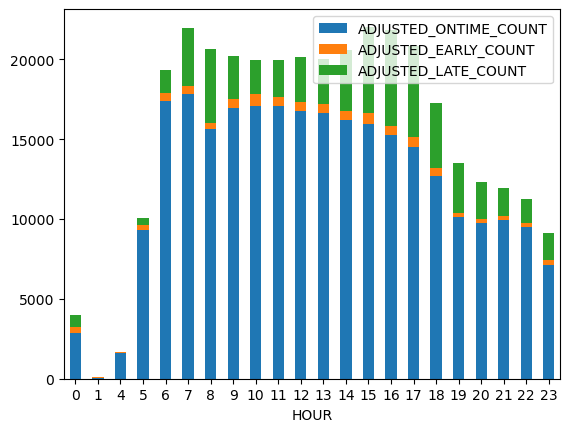

In [57]:
hour_count = wego_hour[['ADJUSTED_ONTIME_COUNT', 'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT']].plot.bar(stacked=True, rot = 0)
fig = hour_count.get_figure()
fig.savefig("hour_count_barplot.png")

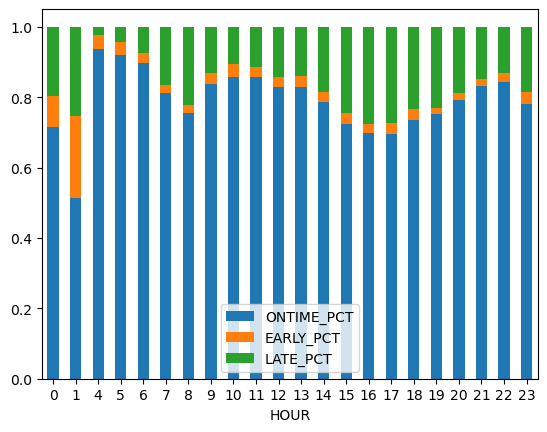

In [58]:
hour_dist = wego_hour[['ONTIME_PCT', 'EARLY_PCT', 'LATE_PCT']].plot.bar(stacked=True, rot = 0)
fig = hour_dist.get_figure()
fig.savefig("hour_dist_barplot.png")

<h3>Day of Week</h3>

In [59]:
wego_weekday = wego[['DAY_OF_WEEK', 'ADJUSTED_ONTIME_COUNT', 'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT']]

In [60]:
wego_weekday

,DAY_OF_WEEK,ADJUSTED_ONTIME_COUNT,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT
0,Tuesday,1,0,0
1,Tuesday,1,0,0
2,Tuesday,1,0,0
3,Tuesday,1,0,0
4,Tuesday,1,0,0
...,...,...,...,...
350324,Saturday,0,0,1
350325,Saturday,0,0,1
350326,Saturday,1,0,0
350327,Saturday,0,0,1


In [61]:
weekdays = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_type = CategoricalDtype(categories=weekdays, ordered=True)

In [62]:
wego_weekday['DAY_OF_WEEK'] = wego_weekday['DAY_OF_WEEK'].astype(day_type)
wego_weekday

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_17376\2239462989.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wego_weekday['DAY_OF_WEEK'] = wego_weekday['DAY_OF_WEEK'].astype(day_type)


,DAY_OF_WEEK,ADJUSTED_ONTIME_COUNT,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT
0,Tuesday,1,0,0
1,Tuesday,1,0,0
2,Tuesday,1,0,0
3,Tuesday,1,0,0
4,Tuesday,1,0,0
...,...,...,...,...
350324,Saturday,0,0,1
350325,Saturday,0,0,1
350326,Saturday,1,0,0
350327,Saturday,0,0,1


In [63]:
wego_weekday = wego_weekday.groupby('DAY_OF_WEEK').sum()

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_17376\436834004.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wego_weekday = wego_weekday.groupby('DAY_OF_WEEK').sum()


In [64]:
wego_weekday

,ADJUSTED_ONTIME_COUNT,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT
DAY_OF_WEEK,,,
Sunday,24253,847,3346
Monday,40319,1665,6005
Tuesday,45502,1685,9587
Wednesday,45009,1635,10297
Thursday,44030,1570,10667
Friday,41973,1552,12389
Saturday,28962,821,6747


In [65]:
weekday_dist = time_dist(wego_weekday['ADJUSTED_ONTIME_COUNT'], wego_weekday['ADJUSTED_EARLY_COUNT'], wego_weekday['ADJUSTED_LATE_COUNT'])

In [66]:
wego_weekday['ONTIME_PCT'] = weekday_dist['on_time']
wego_weekday['EARLY_PCT'] = weekday_dist['early']
wego_weekday['LATE_PCT'] = weekday_dist['late']

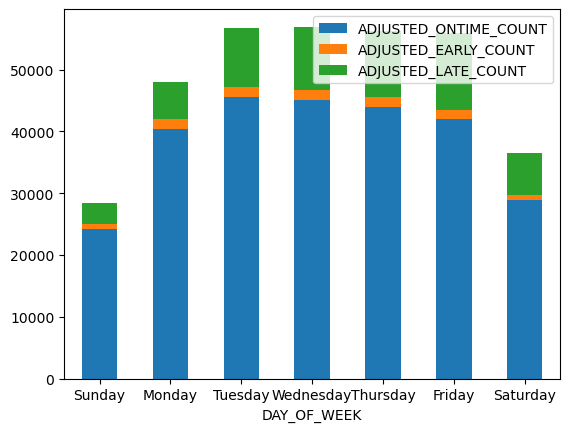

In [67]:
weekday_count = wego_weekday[['ADJUSTED_ONTIME_COUNT', 'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT']].plot.bar(stacked=True, rot = 0)
fig = weekday_count.get_figure()
fig.savefig("weekday_count_barplot.png")

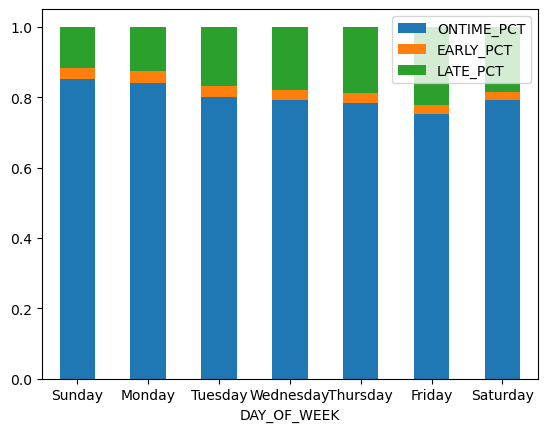

In [68]:
weekday_dist = wego_weekday[['ONTIME_PCT', 'EARLY_PCT', 'LATE_PCT']].plot.bar(stacked=True, rot = 0)
fig = weekday_dist.get_figure()
fig.savefig("weekday_dist_barplot.png")

<h2>How much of a factor does the driver have on on-time performance? The driver is indicated by the OPERATOR variable.</h2>

In [69]:
wego_driver = wego[['OPERATOR', 'ADJUSTED_ONTIME_COUNT', 'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT']]
wego_driver = wego_driver.groupby('OPERATOR').sum()

In [70]:
wego_driver

,ADJUSTED_ONTIME_COUNT,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT
OPERATOR,,,
0,1,0,0
56,3,0,0
235,6,1,5
244,20,0,5
301,19,1,17
...,...,...,...
3149,76,4,8
3156,219,0,71
3165,12,0,20


In [71]:
driver_dist = time_dist(wego_driver['ADJUSTED_ONTIME_COUNT'], wego_driver['ADJUSTED_EARLY_COUNT'], wego_driver['ADJUSTED_LATE_COUNT'])

In [72]:
wego_driver['ONTIME_PCT'] = driver_dist['on_time']
wego_driver['EARLY_PCT'] = driver_dist['early']
wego_driver['LATE_PCT'] = driver_dist['late']

In [91]:
ontime_drivers = wego_driver.sort_values('ONTIME_PCT', ascending=False)
ontime_drivers.head(20)

,ADJUSTED_ONTIME_COUNT,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ONTIME_PCT,EARLY_PCT,LATE_PCT
OPERATOR,,,,,,
0,1,0,0,1.000000,0.000000,0.000000
56,3,0,0,1.000000,0.000000,0.000000
2294,45,0,0,1.000000,0.000000,0.000000
1762,2294,16,23,0.983283,0.006858,0.009859
1706,43,1,0,0.977273,0.022727,0.000000
1597,252,0,6,0.976744,0.000000,0.023256
2639,202,3,2,0.975845,0.014493,0.009662
2573,400,0,12,0.970874,0.000000,0.029126
409,2310,9,61,0.970588,0.003782,0.025630


In [90]:
ontime_drivers.tail(20)

,ADJUSTED_ONTIME_COUNT,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ONTIME_PCT,EARLY_PCT,LATE_PCT
OPERATOR,,,,,,
2747,232,26,211,0.494670,0.055437,0.449893
2309,19,0,20,0.487179,0.000000,0.512821
1800,789,26,810,0.485538,0.016000,0.498462
2137,10,0,11,0.476190,0.000000,0.523810
3120,326,42,319,0.474527,0.061135,0.464338
1904,429,16,461,0.473510,0.017660,0.508830
2714,323,12,380,0.451748,0.016783,0.531469
3101,579,19,699,0.446415,0.014649,0.538936
2312,582,16,714,0.443598,0.012195,0.544207
